# Polarimeter Data Analysis Demo

This notebook demonstrates how a completed polarimeter observing run is analyzed after acquisition.

The assumed workflow is:

1. A 120 second run was collected using the ground pipeline.
2. The exposure directory was copied into `ground/doc/`.
3. The matching `encoder_data_*.pkl` file was copied into `ground/doc/`.
4. This notebook loads the saved data products and demonstrates the scientific analysis steps.

This notebook is not intended to control the camera, motor, or encoder directly. Hardware operation should be done through:

```bash
./run-end-to-end.sh
```
or
```bash
./multi-run.sh
```

In [2]:
from pathlib import Path

import pickle

from datetime import datetime, timezone

import numpy as np

import matplotlib.pyplot as plt

from astropy.io import fits

from PIL import Image

In [3]:
# Notebook location is assumed to be ground/doc/
DOC_DIR = Path.cwd()

# Find exposure directories and encoder files in this folder.
exposure_dirs = sorted([p for p in DOC_DIR.glob("exposures-*") if p.is_dir()])
encoder_files = sorted(DOC_DIR.glob("encoder_data_*.pkl"))

print("Exposure directories:")
for p in exposure_dirs:
    print(" -", p.name)

print("\nEncoder files:")
for p in encoder_files:
    print(" -", p.name)

assert exposure_dirs, "No exposures-* directory found in this notebook folder."
assert encoder_files, "No encoder_data_*.pkl file found in this notebook folder."

EXPOSURE_DIR = exposure_dirs[0]
ENCODER_PKL = encoder_files[0]

print("\nUsing:")
print("EXPOSURE_DIR =", EXPOSURE_DIR)
print("ENCODER_PKL  =", ENCODER_PKL)

Exposure directories:
 - exposures-20260506-165921-443_737138

Encoder files:
 - encoder_data_20260506_170530.pkl

Using:
EXPOSURE_DIR = /home/declan/drone-project/ground/doc/exposures-20260506-165921-443_737138
ENCODER_PKL  = /home/declan/drone-project/ground/doc/encoder_data_20260506_170530.pkl


## Inspect the Run Directory

A completed exposure directory usually contains:

- `raw/` — raw camera `.bin` files
- `processed/fits/` — FITS files generated from raw frames
- `processed/color/` — color PNG previews
- `processed/green/` — green-channel PNG previews
- `plots/` — final analysis plots
- `camera.log` and `motor.log`
- `run_config.log` and `run_command.log`

In [6]:
raw_dir = EXPOSURE_DIR / "raw"
fits_dir = EXPOSURE_DIR / "processed" / "fits"
color_dir = EXPOSURE_DIR / "processed" / "color"
green_dir = EXPOSURE_DIR / "processed" / "green"
plots_dir = EXPOSURE_DIR / "plots"

raw_files = sorted(raw_dir.glob("*.bin")) if raw_dir.exists() else []
fits_files = sorted(fits_dir.glob("*.fits")) if fits_dir.exists() else []
color_pngs = sorted(color_dir.glob("*.png")) if color_dir.exists() else []
green_pngs = sorted(green_dir.glob("*.png")) if green_dir.exists() else []

print(f"Raw .bin files:      {len(raw_files)}")
print(f"FITS files:          {len(fits_files)}")
print(f"Color PNG previews:  {len(color_pngs)}")
print(f"Green PNG previews:  {len(green_pngs)}")
print(f"Plots directory:     {plots_dir.exists()}")

Raw .bin files:      357
FITS files:          357
Color PNG previews:  357
Green PNG previews:  357
Plots directory:     False


Filename: /home/declan/drone-project/ground/doc/exposures-20260506-165921-443_737138/processed/fits/exposure-20260506-210201-144.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   (3096, 2080)   int16 (rescales to uint16)   
  1  RED           1 ImageHDU        10   (1548, 1040)   int16 (rescales to uint16)   
  2  GREEN1        1 ImageHDU        10   (1548, 1040)   int16 (rescales to uint16)   
  3  GREEN2        1 ImageHDU        10   (1548, 1040)   int16 (rescales to uint16)   
  4  BLUE          1 ImageHDU        10   (1548, 1040)   int16 (rescales to uint16)   
  5  COLOR_COMPOSITE    1 ImageHDU        11   (3, 1548, 1040)   int16 (rescales to uint16)   
None

DATE-OBS: 2026-05-06T21:02:01.144Z


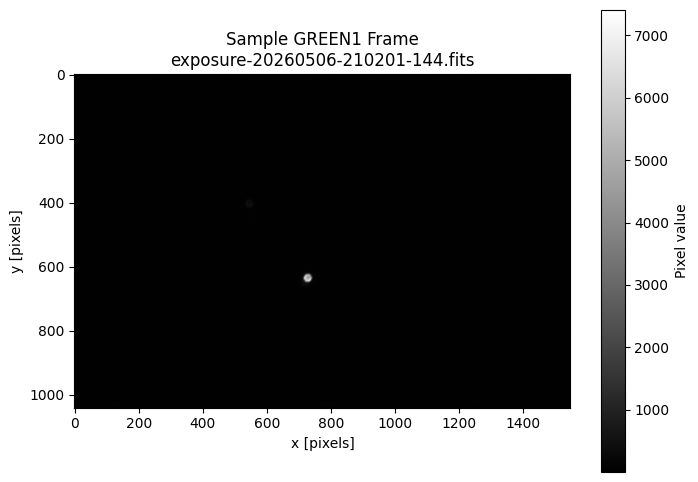

In [7]:
assert fits_files, "No FITS files found. Run process-exposures-batch.py before using this notebook."

sample_fits = fits_files[len(fits_files) // 2]

with fits.open(sample_fits) as hdul:
    print(hdul.info())
    header = hdul[0].header
    print("\nDATE-OBS:", header.get("DATE-OBS"))

    image_data = hdul["GREEN1"].data.astype(float)

plt.figure(figsize=(8, 6))
plt.imshow(image_data, origin="upper", cmap="gray")
plt.colorbar(label="Pixel value")
plt.title(f"Sample GREEN1 Frame\n{sample_fits.name}")
plt.xlabel("x [pixels]")
plt.ylabel("y [pixels]")
plt.show()

## Load Encoder Data

The encoder file contains timestamped encoder counts recorded during the same observing run.

The plotting pipeline later matches each exposure timestamp to the nearest encoder timestamp.

In [8]:
with open(ENCODER_PKL, "rb") as f:
    encoder_data = pickle.load(f)

encoder_times_ms = np.array(list(encoder_data.keys()), dtype=float)
encoder_counts = np.array(list(encoder_data.values()), dtype=float)

encoder_times_s = encoder_times_ms / 1000.0
relative_time_s = encoder_times_s - encoder_times_s[0]

print("Encoder samples:", len(encoder_counts))
print("Start count:", encoder_counts[0])
print("End count:  ", encoder_counts[-1])
print("Delta count:", encoder_counts[-1] - encoder_counts[0])
print("Duration s: ", relative_time_s[-1])

Encoder samples: 5195
Start count: 45404.0
End count:   51131.0
Delta count: 5727.0
Duration s:  366.7019329071045


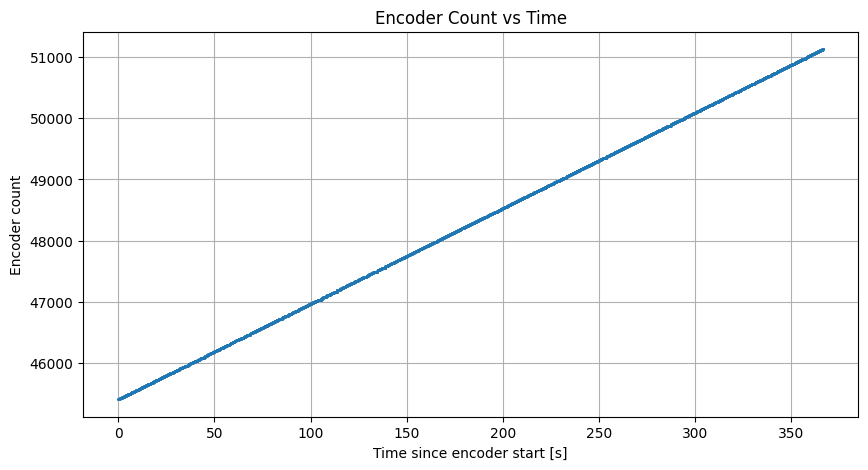

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(relative_time_s, encoder_counts, ".", markersize=2)
plt.xlabel("Time since encoder start [s]")
plt.ylabel("Encoder count")
plt.title("Encoder Count vs Time")
plt.grid(True)
plt.show()

Timestamp monotonic: True
Median dt [s]: 0.06401681900024414
Median count step: 0.0
Min count step: 0.0
Max count step: 22.0


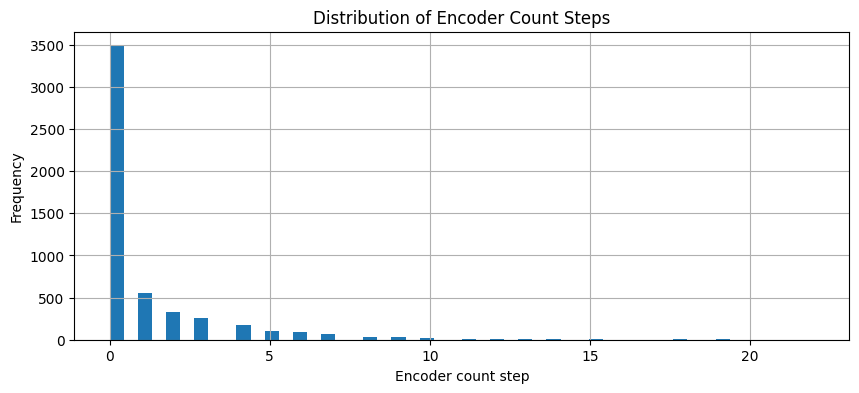

In [10]:
# Basic encoder sanity checks.
dt = np.diff(encoder_times_s)
dc = np.diff(encoder_counts)

print("Timestamp monotonic:", np.all(dt > 0))
print("Median dt [s]:", np.median(dt))
print("Median count step:", np.median(dc))
print("Min count step:", np.min(dc))
print("Max count step:", np.max(dc))

plt.figure(figsize=(10, 4))
plt.hist(dc, bins=50)
plt.xlabel("Encoder count step")
plt.ylabel("Frequency")
plt.title("Distribution of Encoder Count Steps")
plt.grid(True)
plt.show()

## Parse FITS Timestamps

Each FITS file stores a timestamp in the `DATE-OBS` header.  
We use these timestamps to associate each image with the nearest encoder count.

In [11]:
def parse_dateobs(dateobs):
    if dateobs is None:
        return None

    s = str(dateobs).strip()

    if s.endswith("Z"):
        dt = datetime.fromisoformat(s.replace("Z", "+00:00"))
    else:
        dt = datetime.fromisoformat(s)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)

    return dt.timestamp()


fits_timestamps = []
valid_fits_files = []

for fpath in fits_files:
    hdr = fits.getheader(fpath)
    ts = parse_dateobs(hdr.get("DATE-OBS"))
    if ts is not None:
        valid_fits_files.append(fpath)
        fits_timestamps.append(ts)

fits_timestamps = np.array(fits_timestamps, dtype=float)

print("FITS files with valid DATE-OBS:", len(valid_fits_files))
print("First FITS timestamp:", datetime.fromtimestamp(fits_timestamps[0], tz=timezone.utc))
print("Last FITS timestamp: ", datetime.fromtimestamp(fits_timestamps[-1], tz=timezone.utc))

FITS files with valid DATE-OBS: 357
First FITS timestamp: 2026-05-06 20:59:22.632000+00:00
Last FITS timestamp:  2026-05-06 21:05:11.210000+00:00


In [12]:
def nearest_encoder_count(fits_ts, encoder_ts, encoder_counts):
    idx = np.searchsorted(encoder_ts, fits_ts)

    if idx == 0:
        return encoder_counts[0]
    if idx >= len(encoder_ts):
        return encoder_counts[-1]

    before = encoder_ts[idx - 1]
    after = encoder_ts[idx]

    if abs(fits_ts - before) <= abs(fits_ts - after):
        return encoder_counts[idx - 1]
    return encoder_counts[idx]


matched_counts = np.array([
    nearest_encoder_count(ts, encoder_times_s, encoder_counts)
    for ts in fits_timestamps
])

fits_relative_time = fits_timestamps - fits_timestamps[0]

print("Matched exposures:", len(matched_counts))
print("First matched count:", matched_counts[0])
print("Last matched count: ", matched_counts[-1])

Matched exposures: 357
First matched count: 45404.0
Last matched count:  50829.0


In [13]:
def nearest_encoder_count(fits_ts, encoder_ts, encoder_counts):
    idx = np.searchsorted(encoder_ts, fits_ts)

    if idx == 0:
        return encoder_counts[0]
    if idx >= len(encoder_ts):
        return encoder_counts[-1]

    before = encoder_ts[idx - 1]
    after = encoder_ts[idx]

    if abs(fits_ts - before) <= abs(fits_ts - after):
        return encoder_counts[idx - 1]
    return encoder_counts[idx]


matched_counts = np.array([
    nearest_encoder_count(ts, encoder_times_s, encoder_counts)
    for ts in fits_timestamps
])

fits_relative_time = fits_timestamps - fits_timestamps[0]

print("Matched exposures:", len(matched_counts))
print("First matched count:", matched_counts[0])
print("Last matched count: ", matched_counts[-1])

Matched exposures: 357
First matched count: 45404.0
Last matched count:  50829.0


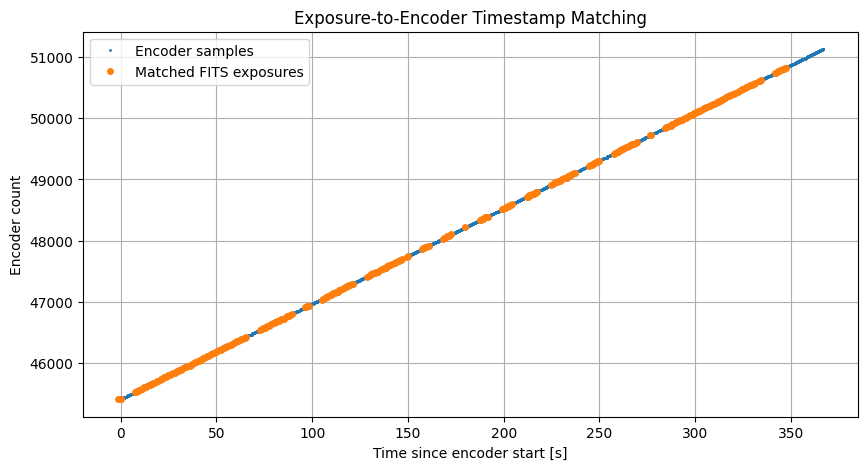

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(relative_time_s, encoder_counts, ".", markersize=2, label="Encoder samples")
plt.plot(
    fits_timestamps - encoder_times_s[0],
    matched_counts,
    "o",
    markersize=4,
    label="Matched FITS exposures"
)
plt.xlabel("Time since encoder start [s]")
plt.ylabel("Encoder count")
plt.title("Exposure-to-Encoder Timestamp Matching")
plt.legend()
plt.grid(True)
plt.show()

## Simple ROI Photometry Demonstration

The production pipeline uses `create-plot.py` for automated ROI extraction and plotting.

Here, we recreate a simplified version of the same idea:

1. Load each FITS frame.
2. Find the brightest pixel in the `GREEN1` extension.
3. Define a small square ROI around it.
4. Estimate background from the full image outside the ROI.
5. Compute a background-subtracted ROI sum.

In [15]:
def simple_roi_photometry(data, half_width=8):
    data = data.astype(float)

    y_peak, x_peak = np.unravel_index(np.argmax(data), data.shape)

    y0 = max(0, y_peak - half_width)
    y1 = min(data.shape[0], y_peak + half_width + 1)
    x0 = max(0, x_peak - half_width)
    x1 = min(data.shape[1], x_peak + half_width + 1)

    roi = data[y0:y1, x0:x1]

    mask = np.ones(data.shape, dtype=bool)
    mask[y0:y1, x0:x1] = False

    background = np.median(data[mask])
    roi_sum = np.sum(roi - background)
    roi_mean = np.mean(roi - background)
    peak_value = data[y_peak, x_peak] - background

    return {
        "x_peak": x_peak,
        "y_peak": y_peak,
        "roi_sum": roi_sum,
        "roi_mean": roi_mean,
        "peak_value": peak_value,
        "bbox": (x0, x1, y0, y1),
    }

In [16]:
roi_sums = []
roi_means = []
peak_values = []
roi_positions = []

for fpath in valid_fits_files:
    data = fits.getdata(fpath, extname="GREEN1")
    result = simple_roi_photometry(data)

    roi_sums.append(result["roi_sum"])
    roi_means.append(result["roi_mean"])
    peak_values.append(result["peak_value"])
    roi_positions.append((result["x_peak"], result["y_peak"]))

roi_sums = np.array(roi_sums)
roi_means = np.array(roi_means)
peak_values = np.array(peak_values)
roi_positions = np.array(roi_positions)

print("Computed photometry for", len(roi_sums), "frames.")

Computed photometry for 357 frames.


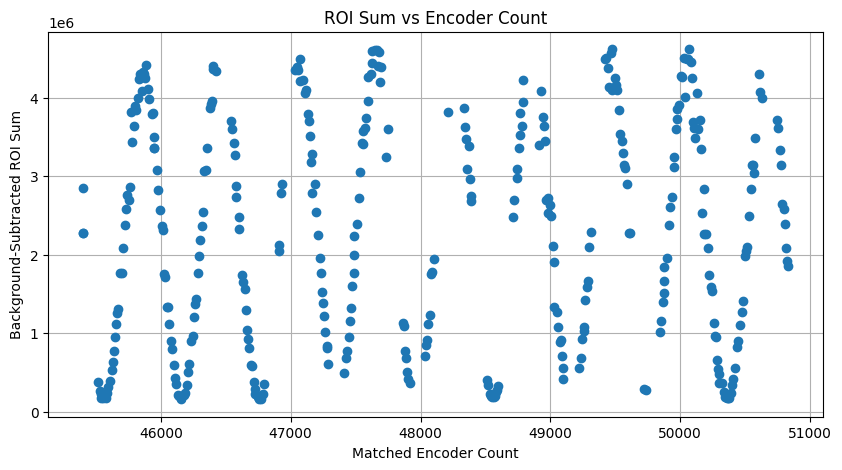

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(matched_counts, roi_sums, "o")
plt.xlabel("Matched Encoder Count")
plt.ylabel("Background-Subtracted ROI Sum")
plt.title("ROI Sum vs Encoder Count")
plt.grid(True)
plt.show()

## Convert Encoder Counts to Plate Angle

The production plotting pipeline uses a configured counts-per-revolution value.

For this notebook, set `COUNTS_PER_REV` to match the value used during the run.

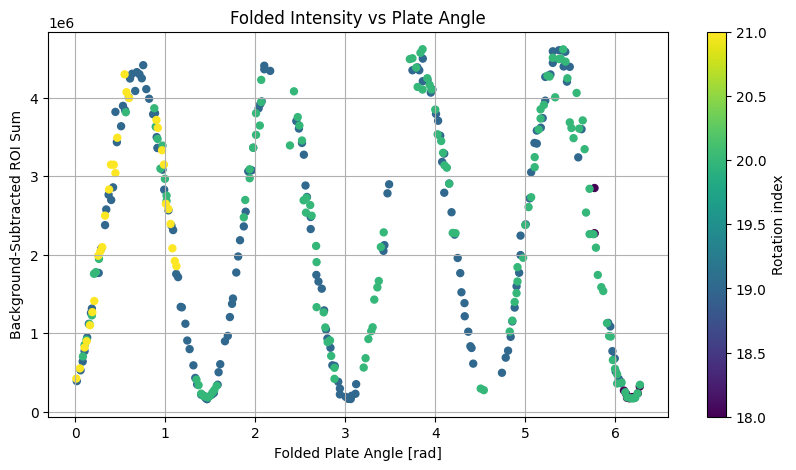

In [18]:
COUNTS_PER_REV = 2400

angles = ((matched_counts / COUNTS_PER_REV) % 1.0) * 2.0 * np.pi
rotation_index = (matched_counts // COUNTS_PER_REV).astype(int)

plt.figure(figsize=(10, 5))
plt.scatter(angles, roi_sums, c=rotation_index, s=25)
plt.xlabel("Folded Plate Angle [rad]")
plt.ylabel("Background-Subtracted ROI Sum")
plt.title("Folded Intensity vs Plate Angle")
plt.colorbar(label="Rotation index")
plt.grid(True)
plt.show()

## Fit a Simple Harmonic Model

A rotating half-wave plate polarimeter can produce periodic intensity modulation.

Here we fit a simple Fourier model:

```text
I(θ) = a0 + a2 cos(2θ) + b2 sin(2θ) + a4 cos(4θ) + b4 sin(4θ)

In [19]:
def design_matrix(theta):
    return np.column_stack([
        np.ones_like(theta),
        np.cos(2 * theta),
        np.sin(2 * theta),
        np.cos(4 * theta),
        np.sin(4 * theta),
    ])


theta = angles
y = roi_sums.astype(float)

finite = np.isfinite(theta) & np.isfinite(y)
theta_fit = theta[finite]
y_fit = y[finite]

X = design_matrix(theta_fit)
beta, *_ = np.linalg.lstsq(X, y_fit, rcond=None)

y_model = X @ beta
residuals = y_fit - y_model

ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

print("Fit coefficients:")
print("a0 =", beta[0])
print("a2 =", beta[1])
print("b2 =", beta[2])
print("a4 =", beta[3])
print("b4 =", beta[4])
print("R² =", r2)

Fit coefficients:
a0 = 2258060.0525989854
a2 = -74520.63445956289
b2 = -34117.60579207276
a4 = -1913737.3157474592
b4 = 893690.549252968
R² = 0.9878620317169804


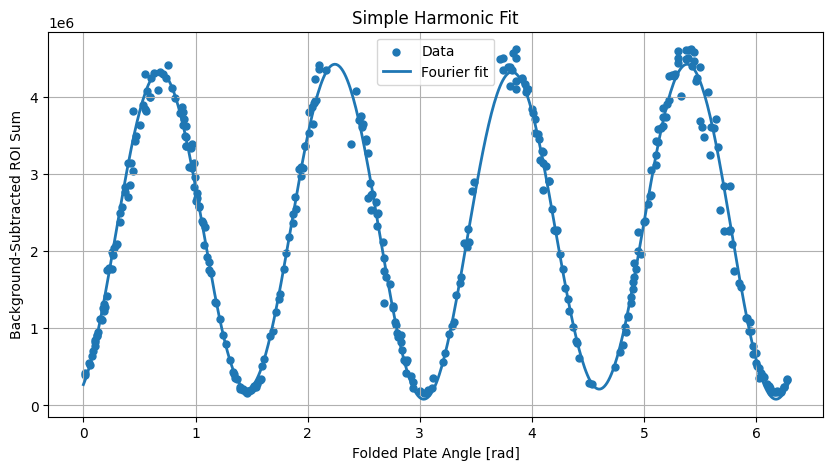

In [20]:
theta_grid = np.linspace(0, 2 * np.pi, 500)
X_grid = design_matrix(theta_grid)
y_grid = X_grid @ beta

plt.figure(figsize=(10, 5))
plt.scatter(theta_fit, y_fit, s=25, label="Data")
plt.plot(theta_grid, y_grid, linewidth=2, label="Fourier fit")
plt.xlabel("Folded Plate Angle [rad]")
plt.ylabel("Background-Subtracted ROI Sum")
plt.title("Simple Harmonic Fit")
plt.legend()
plt.grid(True)
plt.show()

## Display Pipeline-Generated Plots

The production pipeline also saves finalized plots under the `plots/` directory.  
These are the official outputs generated by `create-plot.py`.

In [21]:
plot_files = sorted(plots_dir.glob("**/*.png")) if plots_dir.exists() else []

print("Found", len(plot_files), "pipeline plot files.")

for p in plot_files[:8]:
    print(p.relative_to(EXPOSURE_DIR))

Found 0 pipeline plot files.


In [22]:
if plot_files:
    img_path = plot_files[0]
    img = Image.open(img_path)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(str(img_path.relative_to(EXPOSURE_DIR)))
    plt.show()
else:
    print("No saved pipeline plots found.")

No saved pipeline plots found.


## Summary

This notebook demonstrated the analysis logic behind the polarimeter ground pipeline:

1. Locate a completed exposure directory.
2. Load processed FITS frames.
3. Load encoder measurements.
4. Match exposure timestamps to encoder counts.
5. Extract a simple ROI-based intensity measurement.
6. Convert encoder counts into folded plate angle.
7. Fit a harmonic modulation model.
8. Compare the notebook analysis to saved pipeline outputs.

The production pipeline performs these steps automatically through:

```bash
./run-end-to-end.sh
```
or, for repeated campaigns:
```vash
./multi-run.sh
```

This notebook is intended as a scientific walkthrough of the saved data products rather than the primary hardware-control interface.
